In [15]:

# =============================================================================
# CELL 1 — GLOBAL CONFIGURATION
# =============================================================================
from pathlib import Path
import os
import re
import json
import itertools
import traceback
import warnings
import subprocess
import sys
from datetime import datetime
from functools import reduce

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1) Path to the final Pairwise notebook
# -----------------------------------------------------------------------------
# Put this batch notebook next to Pairwise.ipynb, or set the full path here.
PAIRWISE_NOTEBOOK_PATH = Path("All.ipynb")
AUTO_FIND_PAIRWISE_NOTEBOOK = True

# -----------------------------------------------------------------------------
# 2) Input base datasets
# -----------------------------------------------------------------------------
# Recommended: explicitly list your 5 base datasets here.
# Example:
# RAW_DATASET_FILES = [
#     "output/single_datasets_report_only/Pre_M1.csv",
#     "output/single_datasets_report_only/Post1_M1.csv",
#     "output/single_datasets_report_only/Post2_M1.csv",
#     "output/single_datasets_report_only/ADC_M1.csv",
#     "output/single_datasets_report_only/T2_M1.csv",
# ]
RAW_DATASET_FILES = [
    # EDIT THESE 5 PATHS:
    # "output/single_datasets_report_only/Pre_M1.csv",
    # "output/single_datasets_report_only/Post1_M1.csv",
    # "output/single_datasets_report_only/Post2_M1.csv",
    # "output/single_datasets_report_only/ADC_M1.csv",
    # "output/single_datasets_report_only/T2_M1.csv",
]

# If RAW_DATASET_FILES is empty, auto-discover CSVs from this folder.
AUTO_DISCOVER_DATASETS = True
SOURCE_DATASET_DIR = Path("../Dataset/Breast-Data/Mask1")
DATASET_GLOB_PATTERN = "*.csv"

# The target design is exactly 5 datasets -> C(5,5)=1 all-5 combination.
REQUIRE_EXACTLY_FIVE_DATASETS = True
COMBINATION_SIZE = 5
EXPECTED_N_COMBINATIONS = 1

# -----------------------------------------------------------------------------
# 3) Column names and alignment policy
# -----------------------------------------------------------------------------
LABEL_COL = "Label"
GROUP_COL = "PatientID"

# Candidate columns used to align modalities/phases.
# INFO_NameOfRoi is usually the safest key for your lesion-level radiomics files.
ROI_CANDIDATE_COLUMNS = [
    "INFO_NameOfRoi",
    "NameOfRoi",
    "ROI",
    "ROI_Name",
    "LesionID",
    "Lesion_ID",
]

# Merge-key priority. The code keeps the first key set that exists and is unique in all datasets.
MERGE_KEY_PRIORITY = [
    ["INFO_NameOfRoi"],
    ["PatientID", "INFO_NameOfRoi"],
    ["LesionID"],
    ["Lesion_ID"],
    ["ROI_Name"],
]

# If no unique key exists but all datasets have exactly the same row order,
# this fallback uses row index only after checking the PatientID sequence matches across all datasets.
ALLOW_ROW_ORDER_FALLBACK = True
MERGE_HOW = "inner"

# -----------------------------------------------------------------------------
# 4) Output locations
# -----------------------------------------------------------------------------
ALL5_DATASET_DIR = Path("output/all_5_concat_dataset")
BATCH_ROOT = Path("nested_cv_outputs_all_5_concat_batch")
BATCH_RUN_ROOT = Path("batch_all_5_concat_runner_artifacts")

EXECUTED_NOTEBOOK_DIR = BATCH_RUN_ROOT / "executed_pairwise_notebooks_on_all5"
MISMATCH_REPORT_DIR = BATCH_RUN_ROOT / "label_mismatch_reports"
SUMMARY_DIR = BATCH_RUN_ROOT / "summary_tables"

for p in [ALL5_DATASET_DIR, BATCH_ROOT, BATCH_RUN_ROOT, EXECUTED_NOTEBOOK_DIR, MISMATCH_REPORT_DIR, SUMMARY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# 5) Notebook execution options
# -----------------------------------------------------------------------------
EXECUTE_PAIRWISE_NOTEBOOKS = True
SKIP_EXISTING_SUCCESSFUL_RUNS = False
OVERWRITE_FS_RUNS = True
KERNEL_NAME = "python3"
NOTEBOOK_TIMEOUT_SECONDS = None  # None = no timeout

# This modifies only metadata of Pairwise.ipynb once so papermill knows where to inject parameters.
# It does not create per-combination copies of Pairwise.ipynb.
ADD_PARAMETERS_TAG_TO_PAIRWISE = True

# Optional small in-place patch: make the final zip path all5-specific instead of overwriting one zip.
# It still uses the same Pairwise.ipynb; no per-combination copies are created.
PATCH_FINAL_ZIP_OUTPUT_IN_PLACE = True

print("Configuration loaded.")
print(f"ALL5_DATASET_DIR: {ALL5_DATASET_DIR.resolve()}")
print(f"BATCH_ROOT:       {BATCH_ROOT.resolve()}")
print(f"SUMMARY_DIR:      {SUMMARY_DIR.resolve()}")


Configuration loaded.
ALL5_DATASET_DIR: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/output/all_5_concat_dataset
BATCH_ROOT:       /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/nested_cv_outputs_all_5_concat_batch
SUMMARY_DIR:      /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/batch_all_5_concat_runner_artifacts/summary_tables


In [16]:

# =============================================================================
# CELL 2 — ONE-TIME DEPENDENCY CHECK
# =============================================================================
# papermill is used only to pass parameters directly into the same Pairwise.ipynb.

def ensure_import(import_name, pip_name=None):
    import importlib.util
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"OK: {import_name}")

ensure_import("nbformat", "nbformat")
ensure_import("papermill", "papermill")
ensure_import("statsmodels", "statsmodels")
ensure_import("imblearn", "imbalanced-learn")

import nbformat
import papermill as pm

print("Dependency check completed.")


OK: nbformat
OK: papermill
OK: statsmodels
OK: imblearn
Dependency check completed.


In [17]:

# =============================================================================
# CELL 3 — FILE DISCOVERY AND VALIDATION
# =============================================================================

def find_pairwise_notebook(path: Path) -> Path:
    if path.exists():
        return path.resolve()

    if not AUTO_FIND_PAIRWISE_NOTEBOOK:
        raise FileNotFoundError(f"Pairwise notebook not found: {path}")

    candidates = []
    for root in [Path.cwd(), Path("/kaggle/input"), Path("/mnt/data")]:
        if root.exists():
            try:
                candidates.extend(root.rglob("Pairwise.ipynb"))
            except Exception:
                pass

    candidates = sorted(set(candidates))
    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not find Pairwise.ipynb. Put it next to this notebook or set PAIRWISE_NOTEBOOK_PATH."
        )

    print("Found Pairwise.ipynb candidates:")
    for c in candidates:
        print("  -", c)

    return candidates[0].resolve()


def discover_dataset_files():
    if len(RAW_DATASET_FILES) > 0:
        files = [Path(x) for x in RAW_DATASET_FILES]
    else:
        if not AUTO_DISCOVER_DATASETS:
            raise ValueError("RAW_DATASET_FILES is empty and AUTO_DISCOVER_DATASETS=False.")
        if not SOURCE_DATASET_DIR.exists():
            raise FileNotFoundError(
                f"SOURCE_DATASET_DIR does not exist: {SOURCE_DATASET_DIR}\n"
                "Either create this folder or fill RAW_DATASET_FILES manually."
            )
        files = sorted(SOURCE_DATASET_DIR.glob(DATASET_GLOB_PATTERN))

    # Avoid accidentally picking already-created pairwise/triple/quad/all5 or summary CSVs.
    filtered = []
    for p in files:
        stem_lower = p.stem.lower()
        if any(x in stem_lower for x in [
            "pairwise", "triple", "quad", "all5", "all_5", "summary", "comparison", "random_label"
        ]):
            continue
        filtered.append(p)

    files = [p.resolve() for p in filtered]

    missing = [str(p) for p in files if not p.exists()]
    if missing:
        raise FileNotFoundError("These dataset files were not found:\n" + "\n".join(missing))

    if REQUIRE_EXACTLY_FIVE_DATASETS and len(files) != 5:
        raise ValueError(
            f"Expected exactly 5 base datasets to create C(5,5)=1 all-5 combination, but found {len(files)}.\n"
            "Files found:\n" + "\n".join(str(p) for p in files) + "\n\n"
            "Fix RAW_DATASET_FILES or SOURCE_DATASET_DIR."
        )

    if len(files) < COMBINATION_SIZE:
        raise ValueError(f"Need at least {COMBINATION_SIZE} datasets, found {len(files)}.")

    return files


PAIRWISE_NOTEBOOK_PATH = find_pairwise_notebook(PAIRWISE_NOTEBOOK_PATH)
DATASET_FILES = discover_dataset_files()

print("Pairwise notebook:")
print(" ", PAIRWISE_NOTEBOOK_PATH)

print("\nBase datasets:")
for i, f in enumerate(DATASET_FILES, start=1):
    print(f"{i}. {f}")

expected_combos = len(list(itertools.combinations(DATASET_FILES, COMBINATION_SIZE)))
print(f"\nNumber of all-5 concat combinations to create: {expected_combos}")


Pairwise notebook:
  /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/All.ipynb

Base datasets:
1. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/ADC_M1.csv
2. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post1_M1.csv
3. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post2_M1.csv
4. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Pre_M1.csv
5. /Users/mahla/MyDrive/R

In [18]:

# =============================================================================
# CELL 4 — DATASET READING, TAGGING, AND ALL-5 CONCAT FUNCTIONS
# =============================================================================

DATASET_LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")


def clean_tag_from_path(path):
    """Create a compact dataset tag from filename."""
    stem = Path(path).stem
    suffixes = [
        "_Cleaned", "_cleaned", "_M1_pairwise", "_pairwise", "_M1",
        "_triple", "_triplewise", "_quad", "_quadwise", "_all5", "_all_5", "_allfive"
    ]
    changed = True
    while changed:
        changed = False
        for s in suffixes:
            if stem.endswith(s):
                stem = stem[: -len(s)]
                changed = True
    stem = re.sub(r"[^A-Za-z0-9]+", "_", stem).strip("_")
    return stem


def read_csv_flexible(path):
    """Read comma-, semicolon-, tab-, or whitespace-separated CSV robustly."""
    path = Path(path)
    attempts = [
        dict(sep=None, engine="python"),
        dict(sep=","),
        dict(sep=";"),
        dict(sep="\t"),
        dict(sep=r"\s+", engine="python"),
    ]
    last_error = None
    for kwargs in attempts:
        try:
            df = pd.read_csv(path, **kwargs)
            if df.shape[1] > 1:
                return df
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not read CSV correctly: {path}\nLast error: {last_error}")


def normalize_column_lookup(df):
    return {str(c).strip().lower(): c for c in df.columns}


def resolve_column(df, preferred, candidates=None, required=True, role_name="column"):
    candidates = candidates or []
    lookup = normalize_column_lookup(df)
    for term in [preferred] + list(candidates):
        if term is None:
            continue
        key = str(term).strip().lower()
        if key in lookup:
            return lookup[key]
    if required:
        raise ValueError(
            f"Could not find required {role_name}. Preferred={preferred}, candidates={candidates}. "
            f"Available columns include: {list(df.columns[:20])}"
        )
    return None


def standardize_label_column(df):
    df = df.copy()
    detected_label = resolve_column(
        df,
        LABEL_COL,
        candidates=["label", "Label", "Class", "class", "target", "Target", "diagnosis"],
        required=True,
        role_name="label column",
    )
    if detected_label != LABEL_COL:
        df = df.rename(columns={detected_label: LABEL_COL})
    return df


def find_first_existing_column(df, candidates):
    lookup = normalize_column_lookup(df)
    for c in candidates:
        key = str(c).strip().lower()
        if key in lookup:
            return lookup[key]
    return None


def derive_patient_id(df):
    """Create/normalize PatientID. ROI names such as M1_S2_P1_R_#1 are ideal."""
    df = df.copy()

    if GROUP_COL in df.columns and df[GROUP_COL].notna().any():
        source = df[GROUP_COL].astype(str)
    else:
        roi_col = find_first_existing_column(df, ROI_CANDIDATE_COLUMNS)
        patient_name_col = find_first_existing_column(
            df,
            ["INFO_PatientName", "PatientName", "patient_name", "SubjectID", "CaseID", "ID"],
        )

        if roi_col is not None:
            source = df[roi_col].astype(str)
        elif patient_name_col is not None:
            source = df[patient_name_col].astype(str)
        else:
            raise ValueError(
                "Could not derive PatientID. Provide a PatientID column, INFO_NameOfRoi, or INFO_PatientName."
            )

    extracted = source.str.extract(r"(P\d+)", expand=False)
    fallback = source.str.replace(r"^[A-Za-z0-9]+_D_", "", regex=True)
    fallback = fallback.str.replace(r"[^A-Za-z0-9]+", "_", regex=True).str.strip("_")

    patient_id = extracted.fillna(fallback).astype(str)
    df[GROUP_COL] = patient_id
    return df


def preprocess_base_dataset(path):
    df = read_csv_flexible(path)
    df = df.copy()

    empty_cols = df.columns[df.isna().all()].tolist()
    if empty_cols:
        df = df.drop(columns=empty_cols)

    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    df = standardize_label_column(df)
    df = derive_patient_id(df)

    return df


def choose_merge_keys_multi(dfs):
    """Choose a safe unique merge key shared by all datasets. Avoid many-to-many patient-only merges."""
    candidate_key_sets = []
    candidate_key_sets.extend(MERGE_KEY_PRIORITY)

    for roi_col in ROI_CANDIDATE_COLUMNS:
        candidate_key_sets.append([roi_col])
        candidate_key_sets.append([GROUP_COL, roi_col])

    # PatientID only as last resort, and only if unique in all datasets.
    candidate_key_sets.append([GROUP_COL])

    seen = set()
    for keys in candidate_key_sets:
        keys = [k for k in keys if k is not None]
        key_tuple = tuple(keys)
        if key_tuple in seen:
            continue
        seen.add(key_tuple)

        if all(all(k in df.columns for k in keys) for df in dfs):
            duplicated_counts = [int(df.duplicated(subset=keys).sum()) for df in dfs]
            if all(x == 0 for x in duplicated_counts):
                return keys, "unique_key"

    if ALLOW_ROW_ORDER_FALLBACK:
        lengths = [len(df) for df in dfs]
        if len(set(lengths)) == 1:
            base_patient_order = dfs[0][GROUP_COL].astype(str).reset_index(drop=True)
            same_patient_order = all(
                (base_patient_order == df[GROUP_COL].astype(str).reset_index(drop=True)).all()
                for df in dfs[1:]
            )
            if same_patient_order:
                for df in dfs:
                    df["__row_index_all5_key__"] = np.arange(len(df))
                return ["__row_index_all5_key__"], "row_order_fallback"

    raise ValueError(
        "No safe unique merge key found across all selected datasets. Use a unique ROI/Lesion column "
        "such as INFO_NameOfRoi, or verify row order and PatientID alignment."
    )


def prepare_dataset_for_combo_merge(df, tag, keys):
    """Keep merge keys unprefixed, prefix features by tag, and tag metadata columns to avoid merge suffix ambiguity."""
    df = df.copy()

    meta_candidates = [GROUP_COL, LABEL_COL, "INFO_PatientName"] + ROI_CANDIDATE_COLUMNS
    meta_cols = list(keys)
    for col in meta_candidates:
        if col in df.columns and col not in meta_cols:
            meta_cols.append(col)

    feature_cols = [c for c in df.columns if c not in meta_cols]

    rename_map = {}
    for c in meta_cols:
        if c in keys:
            continue
        rename_map[c] = f"__META__{tag}__{c}"
    for c in feature_cols:
        rename_map[c] = f"{tag}__{c}"

    prepared = df[meta_cols + feature_cols].rename(columns=rename_map)
    renamed_feature_cols = [rename_map[c] for c in feature_cols]
    metadata_map = {c: rename_map.get(c, c) for c in meta_cols}

    return prepared, renamed_feature_cols, metadata_map


def write_mismatch_rows(merged, combo_tag, mismatch_mask, cols, suffix):
    out_path = MISMATCH_REPORT_DIR / f"{combo_tag}_{suffix}.csv"
    cols = [c for c in cols if c in merged.columns]
    merged.loc[mismatch_mask, cols].to_csv(out_path, index=False)
    return out_path


def check_label_consistency(merged, combo_tag, label_cols, keys):
    label_cols = [c for c in label_cols if c in merged.columns]
    if len(label_cols) < 2:
        raise ValueError(f"{combo_tag}: fewer than two label columns were found after merge.")

    base_col = label_cols[0]
    mismatch_mask = pd.Series(False, index=merged.index)
    for c in label_cols[1:]:
        mismatch_mask |= (
            merged[base_col].astype(str).str.strip()
            != merged[c].astype(str).str.strip()
        )

    if mismatch_mask.any():
        out_path = write_mismatch_rows(
            merged,
            combo_tag,
            mismatch_mask,
            keys + label_cols,
            "label_mismatches",
        )
        raise ValueError(
            f"Label mismatch detected for all-5 combination {combo_tag}: {int(mismatch_mask.sum())} rows. "
            f"Report saved to: {out_path}"
        )


def check_group_consistency(merged, combo_tag, group_cols, keys):
    group_cols = [c for c in group_cols if c in merged.columns]
    group_cols = list(dict.fromkeys(group_cols))
    if len(group_cols) < 2:
        return

    base_col = group_cols[0]
    mismatch_mask = pd.Series(False, index=merged.index)
    for c in group_cols[1:]:
        mismatch_mask |= (
            merged[base_col].astype(str).str.strip()
            != merged[c].astype(str).str.strip()
        )

    if mismatch_mask.any():
        out_path = write_mismatch_rows(
            merged,
            combo_tag,
            mismatch_mask,
            keys + group_cols,
            "group_mismatches",
        )
        raise ValueError(
            f"Group mismatch detected for all-5 combination {combo_tag}: {int(mismatch_mask.sum())} rows. "
            f"Report saved to: {out_path}"
        )


def coerce_label_for_modeling(label_series):
    """Keep labels compatible with the downstream notebook; numeric 0/1 labels are preferred."""
    numeric = pd.to_numeric(label_series, errors="coerce")
    if numeric.notna().all():
        return numeric.astype(int)

    labels = label_series.astype(str).str.strip()
    unique_labels = sorted(labels.unique())
    if len(unique_labels) != 2:
        raise ValueError(f"Expected binary labels, found: {unique_labels}")
    mapping = {unique_labels[0]: 0, unique_labels[1]: 1}
    print("Non-numeric labels detected. Applied deterministic mapping:", mapping)
    return labels.map(mapping).astype(int)


def make_dataset_meta_columns(meta, tags, paths, dfs, feature_cols_by_tag):
    for i, (tag, path, df) in enumerate(zip(tags, paths, dfs)):
        letter = DATASET_LETTERS[i]
        meta[f"Dataset_{letter}"] = tag
        meta[f"Dataset_{letter}_Path"] = str(path)
        meta[f"Rows_{letter}"] = int(len(df))
        meta[f"N_Features_{letter}"] = int(len(feature_cols_by_tag[tag]))
    return meta


def build_concat_all5_dataset(paths):
    paths = [Path(p) for p in paths]
    tags = [clean_tag_from_path(p) for p in paths]
    combo_tag = "_".join(tags)
    combo_file_name = f"{combo_tag}_M1_pairwise.csv"  # kept compatible with Pairwise.ipynb naming logic
    combo_output_path = ALL5_DATASET_DIR / combo_file_name

    dfs = [preprocess_base_dataset(p) for p in paths]
    dfs_keyed = [df.copy() for df in dfs]
    keys, key_mode = choose_merge_keys_multi(dfs_keyed)

    prepared_list = []
    feature_cols_by_tag = {}
    metadata_maps = {}

    for tag, df in zip(tags, dfs_keyed):
        prepared, feature_cols, metadata_map = prepare_dataset_for_combo_merge(df, tag, keys)
        prepared_list.append(prepared)
        feature_cols_by_tag[tag] = feature_cols
        metadata_maps[tag] = metadata_map

    merged = reduce(
        lambda left, right: left.merge(right, on=keys, how=MERGE_HOW, validate="one_to_one"),
        prepared_list,
    )

    if len(merged) == 0:
        raise ValueError(f"{combo_tag}: merge produced 0 rows. Check keys={keys} and MERGE_HOW={MERGE_HOW}.")

    label_cols = [metadata_maps[tag].get(LABEL_COL) for tag in tags if metadata_maps[tag].get(LABEL_COL) in merged.columns]
    group_cols = [metadata_maps[tag].get(GROUP_COL) for tag in tags if metadata_maps[tag].get(GROUP_COL) in merged.columns]

    check_label_consistency(merged, combo_tag, label_cols, keys)
    check_group_consistency(merged, combo_tag, group_cols, keys)

    final_df = pd.DataFrame(index=merged.index)

    # PatientID
    if group_cols:
        final_df[GROUP_COL] = merged[group_cols[0]].astype(str)
    elif GROUP_COL in keys and GROUP_COL in merged.columns:
        final_df[GROUP_COL] = merged[GROUP_COL].astype(str)
    else:
        final_df[GROUP_COL] = merged[keys[0]].astype(str)

    # ROI name, if available
    if "INFO_NameOfRoi" in keys and "INFO_NameOfRoi" in merged.columns:
        final_df["INFO_NameOfRoi"] = merged["INFO_NameOfRoi"].astype(str)
    else:
        roi_meta_cols = []
        for tag in tags:
            for roi_col in ROI_CANDIDATE_COLUMNS:
                meta_col = metadata_maps[tag].get(roi_col)
                if meta_col in merged.columns:
                    roi_meta_cols.append(meta_col)
                    break
        if roi_meta_cols:
            final_df["INFO_NameOfRoi"] = merged[roi_meta_cols[0]].astype(str)

    # Patient name, if available
    patient_name_cols = [metadata_maps[tag].get("INFO_PatientName") for tag in tags]
    patient_name_cols = [c for c in patient_name_cols if c in merged.columns]
    if patient_name_cols:
        final_df["INFO_PatientName"] = merged[patient_name_cols[0]].astype(str)

    # Add features from all five datasets.
    for tag in tags:
        for c in feature_cols_by_tag[tag]:
            if c in merged.columns:
                final_df[c] = merged[c]

    final_df[LABEL_COL] = coerce_label_for_modeling(merged[label_cols[0]])

    combo_output_path.parent.mkdir(parents=True, exist_ok=True)
    final_df.to_csv(combo_output_path, index=False)

    label_counts = final_df[LABEL_COL].value_counts().sort_index().to_dict()
    numeric_feature_count = len([c for c in final_df.select_dtypes(include=[np.number]).columns if c != LABEL_COL])

    meta = {
        "All5_Tag": combo_tag,
        "All5_Input_File": str(combo_output_path),
        "Merge_Keys": ",".join(keys),
        "Merge_Key_Mode": key_mode,
        "Merge_How": MERGE_HOW,
        "Rows_After_Merge": int(len(final_df)),
        "N_Features_Total": int(numeric_feature_count),
        "Label_Counts": json.dumps({str(k): int(v) for k, v in label_counts.items()}, ensure_ascii=False),
        "Status": "dataset_created",
        "Error": "",
    }
    meta = make_dataset_meta_columns(meta, tags, paths, dfs, feature_cols_by_tag)

    return combo_output_path, meta


In [19]:

# =============================================================================
# CELL 5 — CREATE THE ALL-5 CONCAT DATASET
# =============================================================================

all5_dataset_rows = []
all5_dataset_paths = []

for combo_paths in itertools.combinations(DATASET_FILES, COMBINATION_SIZE):
    try:
        out_path, meta = build_concat_all5_dataset(combo_paths)
        all5_dataset_paths.append(out_path)
        all5_dataset_rows.append(meta)
        print(
            f"✅ Created: {meta['All5_Tag']} | "
            f"rows={meta['Rows_After_Merge']} | features={meta['N_Features_Total']} | keys={meta['Merge_Keys']}"
        )
    except Exception as e:
        tags = [clean_tag_from_path(p) for p in combo_paths]
        combo_tag = "_".join(tags)
        failed_meta = {
            "All5_Tag": combo_tag,
            "All5_Input_File": "",
            "Merge_Keys": "",
            "Merge_Key_Mode": "",
            "Merge_How": MERGE_HOW,
            "Rows_After_Merge": np.nan,
            "N_Features_Total": np.nan,
            "Label_Counts": "",
            "Status": "dataset_creation_failed",
            "Error": str(e),
        }
        for i, p in enumerate(combo_paths):
            letter = DATASET_LETTERS[i]
            failed_meta[f"Dataset_{letter}"] = tags[i]
            failed_meta[f"Dataset_{letter}_Path"] = str(p)
            failed_meta[f"Rows_{letter}"] = np.nan
            failed_meta[f"N_Features_{letter}"] = np.nan
        all5_dataset_rows.append(failed_meta)
        print(f"❌ Failed to create all-5 dataset: {combo_tag}")
        print(str(e))

df_all5_datasets = pd.DataFrame(all5_dataset_rows)
dataset_log_path = SUMMARY_DIR / "all_5_concat_dataset_creation_log.csv"
df_all5_datasets.to_csv(dataset_log_path, index=False)

print("\nSaved dataset creation log:")
print(dataset_log_path)

display(df_all5_datasets)


✅ Created: ADC_Post1_Post2_Pre_T2 | rows=113 | features=725 | keys=INFO_NameOfRoi

Saved dataset creation log:
batch_all_5_concat_runner_artifacts/summary_tables/all_5_concat_dataset_creation_log.csv


,All5_Tag,All5_Input_File,Merge_Keys,Merge_Key_Mode,Merge_How,Rows_After_Merge,N_Features_Total,Label_Counts,Status,Error,...,Rows_C,N_Features_C,Dataset_D,Dataset_D_Path,Rows_D,N_Features_D,Dataset_E,Dataset_E_Path,Rows_E,N_Features_E
0,ADC_Post1_Post2_Pre_T2,output/all_5_concat_dataset/ADC_Post1_Post2_Pr...,INFO_NameOfRoi,unique_key,inner,113,725,"{""0"": 50, ""1"": 63}",dataset_created,,...,117,145,Pre,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,117,145,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,117,145


In [20]:

# =============================================================================
# CELL 6 — RUN THE SAME Pairwise.ipynb WITH THE ALL-5 DATASET VIA PAPERMILL
# =============================================================================
# No all-5-specific input notebook copy is created here.
# papermill injects a parameters cell at runtime and saves only the executed output notebook.


def ensure_pairwise_accepts_papermill_parameters(nb_path):
    nb_path = Path(nb_path)
    nb = nbformat.read(nb_path, as_version=4)
    if len(nb.cells) == 0:
        raise ValueError("Pairwise.ipynb has no cells.")

    changed = False

    if ADD_PARAMETERS_TAG_TO_PAIRWISE:
        tags = list(nb.cells[0].metadata.get("tags", []))
        if "parameters" not in tags:
            tags.append("parameters")
            nb.cells[0].metadata["tags"] = tags
            changed = True
            print("Added 'parameters' tag to cell 0 of Pairwise.ipynb.")

    if PATCH_FINAL_ZIP_OUTPUT_IN_PLACE:
        for cell in nb.cells:
            if cell.cell_type != "code":
                continue
            src = cell.source
            if "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)" in src:
                new_src = src.replace(
                    "staging_dir = os.path.join(base_working_dir, 'final_outputs')",
                    "staging_dir = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), '_final_outputs_staging')"
                )
                new_src = new_src.replace(
                    "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)",
                    "output_zip_path = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), ACTIVE_RUN_NAME)"
                )
                if new_src != src:
                    cell.source = new_src
                    changed = True
                    print("Patched final zip output path to be all5-specific.")

    if changed:
        try:
            nbformat.write(nb, nb_path)
            print("Pairwise.ipynb updated in place for papermill parameters.")
            return nb_path
        except Exception as e:
            # If the source notebook is read-only, create one reusable parameter-ready copy.
            # This is not a per-run copy; it is only a single fallback notebook.
            fallback_path = BATCH_RUN_ROOT / "Pairwise_parameter_ready_for_all5_run.ipynb"
            nbformat.write(nb, fallback_path)
            print(f"Could not write to original Pairwise.ipynb: {e}")
            print(f"Using one reusable parameter-ready copy instead: {fallback_path}")
            return fallback_path.resolve()
    else:
        print("Pairwise.ipynb already parameter-ready.")
        return nb_path


def final_all5_summary_exists(all5_tag):
    summary_path = (
        BATCH_ROOT
        / all5_tag
        / "fs_method_comparison"
        / "_comparison_summary"
        / "publication_fs_comparison_best_per_method.csv"
    )
    return summary_path.exists()


def build_pairwise_parameters_for_all5(all5_input_file, all5_tag):
    all5_input_file = Path(all5_input_file).resolve()
    output_dir = Path("output/cleaned_all_5_concat") / all5_tag
    dataset_output_root = BATCH_ROOT / all5_tag
    cleaned_dataset_path = output_dir / f"{all5_input_file.stem}_Cleaned.csv"

    return {
        "INPUT_FILE": str(all5_input_file),
        "DATASET_TAG": str(all5_tag),
        "BATCH_ROOT": str(BATCH_ROOT),
        "OUTPUT_DIR": str(output_dir),
        "TARGET_COLUMN": str(LABEL_COL),
        "DATASET_OUTPUT_ROOT": str(dataset_output_root),
        "CLEANED_DATASET_PATH": str(cleaned_dataset_path),
        "OVERWRITE_FS_RUNS": bool(OVERWRITE_FS_RUNS),
    }


PAIRWISE_EXEC_NOTEBOOK_PATH = ensure_pairwise_accepts_papermill_parameters(PAIRWISE_NOTEBOOK_PATH)

run_rows = []

if EXECUTE_PAIRWISE_NOTEBOOKS:
    for _, row in df_all5_datasets.iterrows():
        if row["Status"] != "dataset_created":
            run_rows.append({
                "All5_Tag": row["All5_Tag"],
                "Run_Status": "not_run_dataset_creation_failed",
                "Executed_Notebook": "",
                "Error": row.get("Error", ""),
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        all5_tag = row["All5_Tag"]
        all5_input_file = row["All5_Input_File"]

        if SKIP_EXISTING_SUCCESSFUL_RUNS and final_all5_summary_exists(all5_tag):
            print(f"⏭️ Skipping existing successful run: {all5_tag}")
            run_rows.append({
                "All5_Tag": all5_tag,
                "Run_Status": "skipped_existing",
                "Executed_Notebook": "",
                "Error": "",
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        params = build_pairwise_parameters_for_all5(all5_input_file, all5_tag)
        executed_path = EXECUTED_NOTEBOOK_DIR / f"{all5_tag}__Pairwise_executed_on_all5.ipynb"

        started = datetime.now().isoformat(timespec="seconds")
        print("\n" + "=" * 100)
        print(f"RUNNING ALL-5: {all5_tag}")
        print("Input:", all5_input_file)
        print("Output root:", params["DATASET_OUTPUT_ROOT"])
        print("=" * 100)

        try:
            pm.execute_notebook(
                input_path=str(PAIRWISE_EXEC_NOTEBOOK_PATH),
                output_path=str(executed_path),
                parameters=params,
                kernel_name=KERNEL_NAME,
                cwd=str(Path.cwd()),
                progress_bar=True,
                log_output=False,
                request_save_on_cell_execute=True,
                execution_timeout=NOTEBOOK_TIMEOUT_SECONDS,
            )
            finished = datetime.now().isoformat(timespec="seconds")
            run_rows.append({
                "All5_Tag": all5_tag,
                "Run_Status": "completed",
                "Executed_Notebook": str(executed_path),
                "Error": "",
                "Started_At": started,
                "Finished_At": finished,
            })
            print(f"✅ Completed: {all5_tag}")
        except Exception as e:
            finished = datetime.now().isoformat(timespec="seconds")
            error_text = traceback.format_exc()
            fail_path = EXECUTED_NOTEBOOK_DIR / f"{all5_tag}__FAILED_error.txt"
            fail_path.write_text(error_text, encoding="utf-8")

            run_rows.append({
                "All5_Tag": all5_tag,
                "Run_Status": "failed",
                "Executed_Notebook": str(executed_path) if executed_path.exists() else "",
                "Error": str(e),
                "Started_At": started,
                "Finished_At": finished,
            })

            print(f"❌ Failed: {all5_tag}")
            print(str(e))
else:
    print("EXECUTE_PAIRWISE_NOTEBOOKS=False. All-5 dataset was created but Pairwise.ipynb was not executed.")
    for _, row in df_all5_datasets.iterrows():
        run_rows.append({
            "All5_Tag": row["All5_Tag"],
            "Run_Status": "not_executed",
            "Executed_Notebook": "",
            "Error": "",
            "Started_At": "",
            "Finished_At": "",
        })

df_run_log = pd.DataFrame(run_rows)
run_log_path = SUMMARY_DIR / "all_5_concat_notebook_run_log.csv"
df_run_log.to_csv(run_log_path, index=False)

print("\nRun log saved:")
print(run_log_path)
display(df_run_log)


Passed unknown parameter: OVERWRITE_FS_RUNS


Pairwise.ipynb already parameter-ready.

RUNNING ALL-5: ADC_Post1_Post2_Pre_T2
Input: output/all_5_concat_dataset/ADC_Post1_Post2_Pre_T2_M1_pairwise.csv
Output root: nested_cv_outputs_all_5_concat_batch/ADC_Post1_Post2_Pre_T2


Executing:   0%|          | 0/67 [00:00<?, ?cell/s]

✅ Completed: ADC_Post1_Post2_Pre_T2

Run log saved:
batch_all_5_concat_runner_artifacts/summary_tables/all_5_concat_notebook_run_log.csv


,All5_Tag,Run_Status,Executed_Notebook,Error,Started_At,Finished_At
0,ADC_Post1_Post2_Pre_T2,completed,batch_all_5_concat_runner_artifacts/executed_p...,,2026-06-29T22:19:53,2026-06-29T22:27:27


In [21]:

# =============================================================================
# CELL 7 — COLLECT BEST RESULTS FROM THE ALL-5 RUN
# =============================================================================

def read_best_result_for_all5(all5_tag):
    all5_root = BATCH_ROOT / all5_tag
    summary_root = all5_root / "fs_method_comparison" / "_comparison_summary"

    ranking_path = summary_root / "fs_method_composite_ranking.csv"
    publication_path = summary_root / "publication_fs_comparison_best_per_method.csv"
    best_per_method_path = summary_root / "fs_comparison_best_model_per_method.csv"
    all_models_path = summary_root / "fs_comparison_all_models.csv"

    if ranking_path.exists():
        df_source = pd.read_csv(ranking_path)
        source_path = ranking_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty ranking table: {ranking_path}")
        best = df_source.iloc[0].copy()

    elif publication_path.exists():
        df_source = pd.read_csv(publication_path)
        source_path = publication_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty publication table: {publication_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    elif best_per_method_path.exists():
        df_source = pd.read_csv(best_per_method_path)
        source_path = best_per_method_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty best-per-method table: {best_per_method_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    else:
        raise FileNotFoundError(
            f"No comparison summary found for {all5_tag}. Expected one of:\n"
            f"  {ranking_path}\n"
            f"  {publication_path}\n"
            f"  {best_per_method_path}"
        )

    result = {"All5_Tag": all5_tag, "Result_Source": str(source_path)}

    preferred_cols = [
        "Experiment_ID",
        "FS_METHOD",
        "FS_N_FEATURES",
        "USE_SMOTE",
        "Model",
        "Mean_AUC",
        "Std_AUC",
        "Pooled_AUC",
        "Mean_PR_AUC",
        "Pooled_PR_AUC",
        "Mean_Bal_Acc",
        "Pooled_Bal_Acc",
        "Mean_F1",
        "Pooled_F1",
        "Mean_Specificity",
        "Pooled_Specificity",
        "Avg_Features",
        "N_Unique_Selected_Features",
        "Max_Selection_Count",
        "Mean_Selection_Count",
        "Composite_Rank_Score",
        "Run_Name",
        "Run_Dir",
    ]

    for c in preferred_cols:
        result[c] = best[c] if c in best.index else np.nan

    return result


summary_rows = []
full_best_tables = []
full_all_model_tables = []

for _, dataset_row in df_all5_datasets.iterrows():
    all5_tag = dataset_row["All5_Tag"]
    base_info = dataset_row.to_dict()

    if dataset_row["Status"] != "dataset_created":
        base_info.update({
            "Final_Status": "not_run_dataset_creation_failed",
            "Run_Status": "not_run_dataset_creation_failed",
            "Result_Error": dataset_row.get("Error", ""),
        })
        summary_rows.append(base_info)
        continue

    run_status = "unknown"
    if "df_run_log" in globals() and len(df_run_log) > 0:
        match = df_run_log[df_run_log["All5_Tag"] == all5_tag]
        if len(match) > 0:
            run_status = match.iloc[0]["Run_Status"]

    try:
        best_result = read_best_result_for_all5(all5_tag)
        base_info.update(best_result)
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "success",
            "Result_Error": "",
        })
        summary_rows.append(base_info)

        best_per_method_path = (
            BATCH_ROOT / all5_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_best_model_per_method.csv"
        )
        if best_per_method_path.exists():
            df_tmp = pd.read_csv(best_per_method_path)
            df_tmp.insert(0, "All5_Tag", all5_tag)
            for idx, col in enumerate(["Dataset_A", "Dataset_B", "Dataset_C", "Dataset_D", "Dataset_E"], start=1):
                if col in dataset_row.index:
                    df_tmp.insert(idx, col, dataset_row[col])
            full_best_tables.append(df_tmp)

        all_models_path = (
            BATCH_ROOT / all5_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_all_models.csv"
        )
        if all_models_path.exists():
            df_tmp = pd.read_csv(all_models_path)
            df_tmp.insert(0, "All5_Tag", all5_tag)
            for idx, col in enumerate(["Dataset_A", "Dataset_B", "Dataset_C", "Dataset_D", "Dataset_E"], start=1):
                if col in dataset_row.index:
                    df_tmp.insert(idx, col, dataset_row[col])
            full_all_model_tables.append(df_tmp)

    except Exception as e:
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "result_collection_failed",
            "Result_Error": str(e),
        })
        summary_rows.append(base_info)


df_all_5_concat_summary = pd.DataFrame(summary_rows)

if "Mean_AUC" in df_all_5_concat_summary.columns:
    df_all_5_concat_summary["_sort_auc"] = pd.to_numeric(df_all_5_concat_summary["Mean_AUC"], errors="coerce")
    df_all_5_concat_summary = df_all_5_concat_summary.sort_values(
        ["Final_Status", "_sort_auc"],
        ascending=[False, False],
        na_position="last",
    ).drop(columns=["_sort_auc"]).reset_index(drop=True)

summary_path = SUMMARY_DIR / "all_5_concat_summary.csv"
df_all_5_concat_summary.to_csv(summary_path, index=False)

print("Main summary saved:")
print(summary_path)

if full_best_tables:
    df_full_best = pd.concat(full_best_tables, ignore_index=True)
    full_best_path = SUMMARY_DIR / "all_5_concat_full_best_per_fs_method.csv"
    df_full_best.to_csv(full_best_path, index=False)
    print("Full best-per-FS-method table saved:")
    print(full_best_path)
else:
    df_full_best = pd.DataFrame()

if full_all_model_tables:
    df_full_all_models = pd.concat(full_all_model_tables, ignore_index=True)
    full_all_models_path = SUMMARY_DIR / "all_5_concat_full_all_models.csv"
    df_full_all_models.to_csv(full_all_models_path, index=False)
    print("Full all-model table saved:")
    print(full_all_models_path)
else:
    df_full_all_models = pd.DataFrame()


display_cols = [
    "All5_Tag",
    "Dataset_A",
    "Dataset_B",
    "Dataset_C",
    "Dataset_D",
    "Dataset_E",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "Final_Status",
    "FS_METHOD",
    "FS_N_FEATURES",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Result_Error",
]

display(df_all_5_concat_summary[[c for c in display_cols if c in df_all_5_concat_summary.columns]])


Main summary saved:
batch_all_5_concat_runner_artifacts/summary_tables/all_5_concat_summary.csv
Full best-per-FS-method table saved:
batch_all_5_concat_runner_artifacts/summary_tables/all_5_concat_full_best_per_fs_method.csv
Full all-model table saved:
batch_all_5_concat_runner_artifacts/summary_tables/all_5_concat_full_all_models.csv


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Rows_After_Merge,N_Features_Total,Label_Counts,Final_Status,...,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features,Run_Name,Result_Error
0,ADC_Post1_Post2_Pre_T2,ADC,Post1,Post2,Pre,T2,113,725,"{""0"": 50, ""1"": 63}",success,...,0.761032,0.074115,0.728889,0.787376,0.763131,0.716706,8.8,37,mrmr_then_elasticnet_no_corr_auto_k_no_smote,


Publication-style summary saved:
batch_all_5_concat_runner_artifacts/summary_tables/publication_all_5_concat_summary.csv


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Rows_After_Merge,N_Features_Total,Label_Counts,FS_METHOD,...,Mean_Bal_Acc,Pooled_Bal_Acc,Mean_F1,Pooled_F1,Avg_Features,N_Unique_Selected_Features,Run_Name,Run_Dir,Final_Status,Result_Error
0,ADC_Post1_Post2_Pre_T2,ADC,Post1,Post2,Pre,T2,113,725,"{""0"": 50, ""1"": 63}",mrmr_then_elasticnet_no_corr,...,0.716706,0.683333,0.707002,0.7,8.8,37,mrmr_then_elasticnet_no_corr_auto_k_no_smote,nested_cv_outputs_all_5_concat_batch/ADC_Post1...,success,


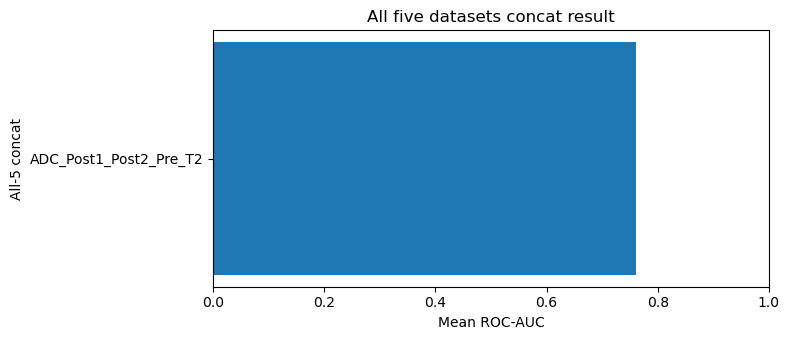

Plot saved:
batch_all_5_concat_runner_artifacts/summary_tables/all_5_concat_mean_auc_barplot.png


In [22]:

# =============================================================================
# CELL 8 — PUBLICATION-STYLE COMPACT TABLE AND OPTIONAL PLOT
# =============================================================================

publication_cols = [
    "All5_Tag",
    "Dataset_A",
    "Dataset_B",
    "Dataset_C",
    "Dataset_D",
    "Dataset_E",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "FS_METHOD",
    "FS_N_FEATURES",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Pooled_Bal_Acc",
    "Mean_F1",
    "Pooled_F1",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Run_Dir",
    "Final_Status",
    "Result_Error",
]

available_publication_cols = [c for c in publication_cols if c in df_all_5_concat_summary.columns]
df_publication_all_5 = df_all_5_concat_summary[available_publication_cols].copy()

publication_path = SUMMARY_DIR / "publication_all_5_concat_summary.csv"
df_publication_all_5.to_csv(publication_path, index=False)

print("Publication-style summary saved:")
print(publication_path)

display(df_publication_all_5)

# Optional simple plot of Mean_AUC. With all 5 datasets there is only one bar.
try:
    import matplotlib.pyplot as plt

    plot_df = df_publication_all_5.copy()
    plot_df["Mean_AUC_numeric"] = pd.to_numeric(plot_df.get("Mean_AUC"), errors="coerce")
    plot_df = plot_df.dropna(subset=["Mean_AUC_numeric"])

    if len(plot_df) > 0:
        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.barh(plot_df["All5_Tag"], plot_df["Mean_AUC_numeric"])
        ax.set_xlabel("Mean ROC-AUC")
        ax.set_ylabel("All-5 concat")
        ax.set_title("All five datasets concat result")
        ax.set_xlim(0, 1)
        plt.tight_layout()

        plot_path = SUMMARY_DIR / "all_5_concat_mean_auc_barplot.png"
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Plot saved:")
        print(plot_path)

except Exception as e:
    print("Plot skipped:", e)
